# 01 - Data split và patient sampling

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [26]:
ROOT = Path('..').resolve() if Path('.').resolve().name == 'notebook' else Path('.').resolve()
DATA_DIR = ROOT/'data'

DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

labels = pd.read_csv(DATA_DIR/'Data_Entry_2017.csv')
with open(DATA_DIR/'train_val_list.txt', 'r') as file:
    train_list = file.read().split('\n')

with open(DATA_DIR/'test_list.txt', 'r') as file:
    test_list = file.read().split('\n')

In [27]:
labels = labels.rename(columns={
    'Image Index': 'Image_index',
    'Finding Labels': 'Finding_labels',
    'Patient ID': 'Patient_id'
})
labels['Patient_id'] = labels['Patient_id'].astype(str)
label_cols = labels['Finding_labels'].str.get_dummies(sep='|')
label_cols = label_cols[DISEASES] #Drop No_Finding
df = pd.concat([labels[['Image_index', 'Patient_id']], label_cols], axis=1)

In [28]:
df_train = df[df['Image_index'].isin(train_list)].copy()
df_test = df[df['Image_index'].isin(test_list)].copy()
assert set(df_train['Patient_id']).isdisjoint(df_test['Patient_id'])

#Split patient
train = df_train.groupby('Patient_id', as_index=False)[DISEASES].max()
test = df_test.groupby('Patient_id', as_index=False)[DISEASES].max()

train_n = 5000
test_n = 500

msss_train = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=train_n, random_state=42)
_, idx_train = next(msss_train.split(train[['Patient_id']], train[DISEASES]))
train_subset = train.iloc[idx_train].reset_index(drop=True)

msss_test = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_n, random_state=42)
_, idx_test = next(msss_test.split(test[['Patient_id']], test[DISEASES]))
test_subset = test.iloc[idx_test].reset_index(drop=True)

train_subset_patient_ids = train_subset['Patient_id'].astype(str).tolist()
test_subset_patient_ids = test_subset['Patient_id'].astype(str).tolist()

#Output df
df_train_subset = df_train[df_train['Patient_id'].isin(train_subset_patient_ids)].reset_index(drop=True)
df_test_subset = df_test[df_test['Patient_id'].isin(test_subset_patient_ids)].reset_index(drop=True)
assert set(df_train_subset['Patient_id']).isdisjoint(df_test_subset['Patient_id'])

Checking class distribution on full and subset dataset

In [29]:
# Full dataset
print('Train shape:', df_train.shape)
print('Test shape:', df_test.shape)
# Subset dataset
print('Train subset shape:', df_train_subset.shape)
print('Test subset shape:', df_test_subset.shape)

test_ratio = len(df_test) / (len(df_train) + len(df_test))
test_subset_ratio = len(df_test_subset) / (len(df_train_subset) + len(df_test_subset))

print(f'Full dataset ratio: {test_ratio:.2%}')
print(f'Subset dataset ratio: {test_subset_ratio:.2%}')

Train shape: (86524, 16)
Test shape: (25596, 16)
Train subset shape: (15155, 16)
Test subset shape: (4788, 16)
Full dataset ratio: 22.83%
Subset dataset ratio: 24.01%


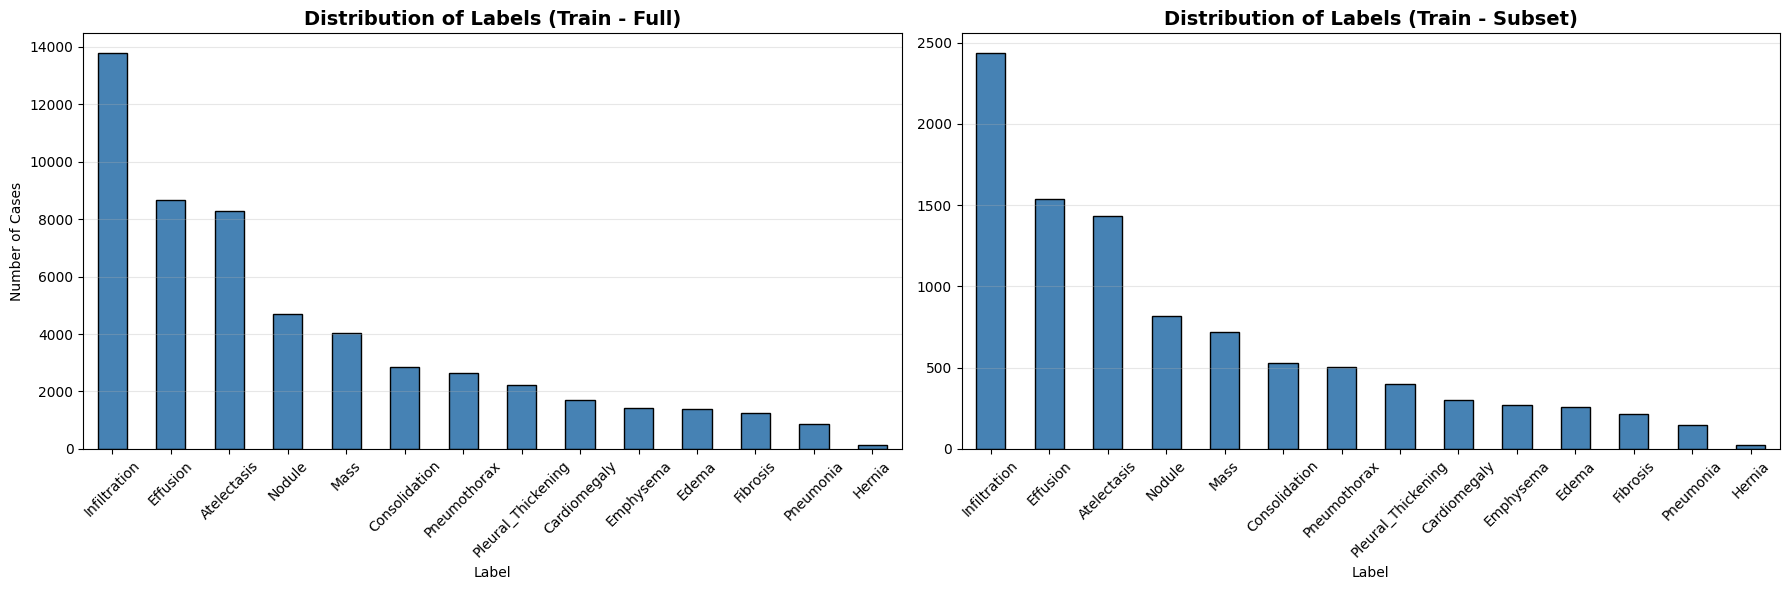


Disease Prevalence (Train - Full) (%):
Infiltration          15.93
Effusion              10.01
Atelectasis            9.57
Nodule                 5.44
Mass                   4.66
Consolidation          3.30
Pneumothorax           3.05
Pleural_Thickening     2.59
Cardiomegaly           1.97
Emphysema              1.64
Edema                  1.59
Fibrosis               1.45
Pneumonia              1.01
Hernia                 0.16
dtype: float64

Disease Prevalence (Train - Subset) (%):
Infiltration          16.07
Effusion              10.16
Atelectasis            9.47
Nodule                 5.39
Mass                   4.73
Consolidation          3.50
Pneumothorax           3.31
Pleural_Thickening     2.65
Cardiomegaly           1.97
Emphysema              1.80
Edema                  1.70
Fibrosis               1.41
Pneumonia              0.98
Hernia                 0.14
dtype: float64


In [30]:
#Train
disease_counts_train = df_train[DISEASES].sum().sort_values(ascending=False)
disease_counts_train_subset = df_train_subset[DISEASES].sum().reindex(disease_counts_train.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full
disease_counts_train.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Labels (Train - Full)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Number of Cases')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Subset
disease_counts_train_subset.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Labels (Train - Subset)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Percentage of disease labels
disease_pct_train = (disease_counts_train / len(df_train) * 100).round(2)
print(f'\nDisease Prevalence (Train - Full) (%):\n{disease_pct_train}')
disease_pct_train_subset = (disease_counts_train_subset / len(df_train_subset) * 100).round(2)
print(f'\nDisease Prevalence (Train - Subset) (%):\n{disease_pct_train_subset}')

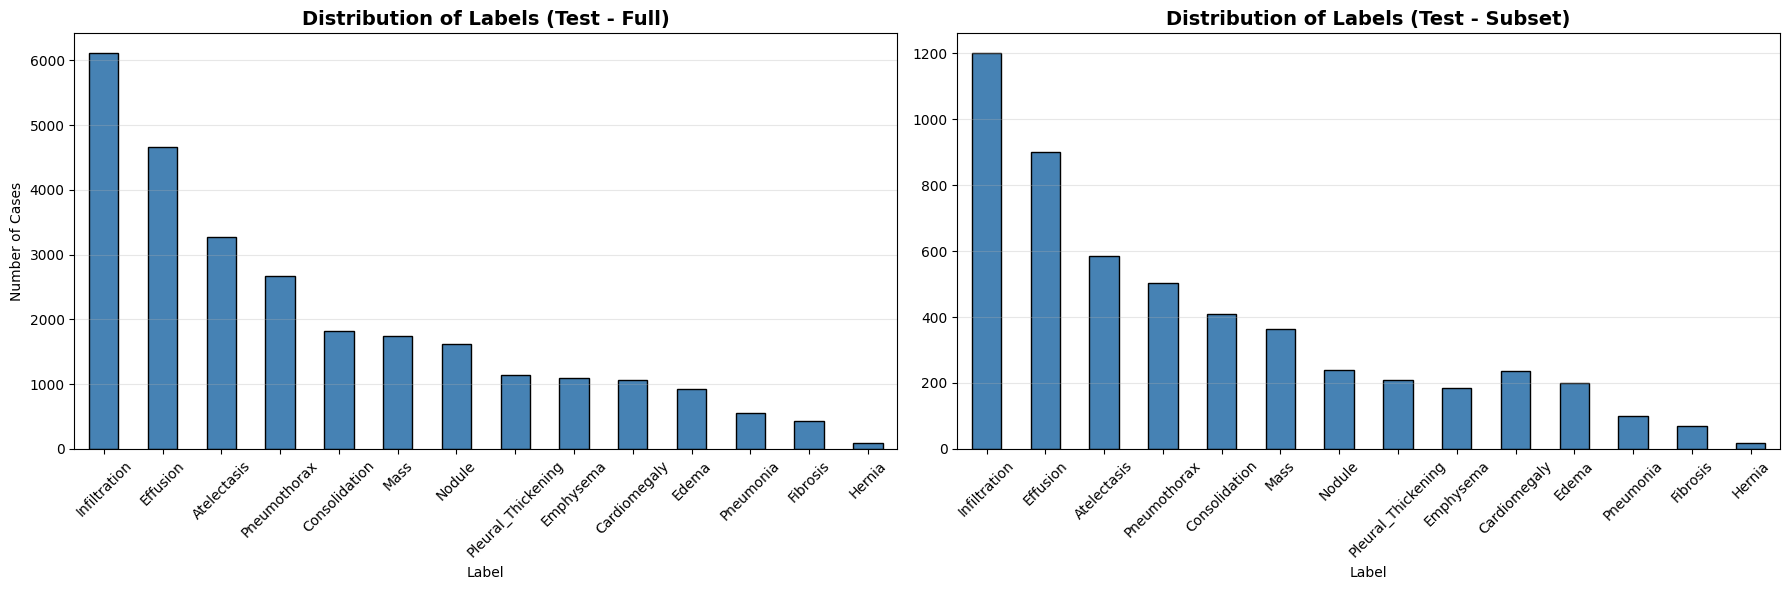


Disease Prevalence (Test - Full) (%):
Infiltration          23.88
Effusion              18.20
Atelectasis           12.81
Pneumothorax          10.41
Consolidation          7.09
Mass                   6.83
Nodule                 6.34
Pleural_Thickening     4.47
Emphysema              4.27
Cardiomegaly           4.18
Edema                  3.61
Pneumonia              2.17
Fibrosis               1.70
Hernia                 0.34
dtype: float64

Disease Prevalence (Test - Subset) (%):
Infiltration          25.08
Effusion              18.80
Atelectasis           12.22
Pneumothorax          10.51
Consolidation          8.52
Mass                   7.58
Nodule                 4.97
Pleural_Thickening     4.39
Emphysema              3.88
Cardiomegaly           4.93
Edema                  4.20
Pneumonia              2.11
Fibrosis               1.46
Hernia                 0.40
dtype: float64


In [31]:
#Test
disease_counts_test = df_test[DISEASES].sum().sort_values(ascending=False)
disease_counts_test_subset = df_test_subset[DISEASES].sum().reindex(disease_counts_test.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full
disease_counts_test.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Labels (Test - Full)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Number of Cases')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Subset
disease_counts_test_subset.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Labels (Test - Subset)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Percentage of disease labels
disease_pct_test = (disease_counts_test / len(df_test) * 100).round(2)
print(f'\nDisease Prevalence (Test - Full) (%):\n{disease_pct_test}')
disease_pct_test_subset = (disease_counts_test_subset / len(df_test_subset) * 100).round(2)
print(f'\nDisease Prevalence (Test - Subset) (%):\n{disease_pct_test_subset}')

In [32]:
train_images_out = df_train_subset['Image_index'].astype(str).sort_values().tolist()
test_images_out = df_test_subset['Image_index'].astype(str).sort_values().tolist()

(DATA_DIR / 'train_subset.txt').write_text('\n'.join(train_images_out) + '\n', encoding='utf-8')
(DATA_DIR / 'test_subset.txt').write_text('\n'.join(test_images_out) + '\n', encoding='utf-8')

81396